# Generate various graphs from the annotation counts

In [ ]:
%pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

In [ ]:
# is this used anywhere???
#import matplotlib.cm as cm
#import numpy as np

## Overview plots of experiment 1 and experiment 2

In [2]:
all_overview = pd.read_csv('tables/all_overview.csv')
all_overview = all_overview.drop(columns=['Unnamed: 0'])


In [3]:
all_overview_avg = all_overview[all_overview['method'] == 'average'] #reset_index(names=['dataset'])
all_overview_avg.set_index('dataset', inplace=True)
all_overview_avg

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other
dataset,,,,,
bcms_twitter,average,3.7,24.9,69.0,2.4
bcms_setimes,average,13.2,35.2,49.9,2.2
finnish_suomi24,average,7.5,44.4,48.0,0.0
german_jodel,average,7.9,14.1,78.0,0.0
greek_dialects,average,10.7,28.8,60.5,0.0
scandinavian_slide,average,18.8,52.9,26.4,2.9
estonian_voro,average,20.3,68.6,8.8,2.2


In [4]:
all_overview = all_overview[all_overview['method'] != 'average']
all_overview

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
1,"IG, $p=0.1$",4.0,19.8,73.2,3.0,bcms_twitter
2,"IG, $p=0.6$",2.2,27.0,67.2,3.5,bcms_twitter
3,"LIME, $p=0.1$",5.2,28.2,64.8,1.8,bcms_twitter
4,"LIME, $p=0.6$",3.8,27.3,67.0,2.0,bcms_twitter
5,"LOO, $p=0.1$",3.2,19.5,75.5,1.8,bcms_twitter
6,"LOO, $p=0.6$",2.2,24.2,71.0,2.5,bcms_twitter
7,"SHAP, $p=0.1$",4.8,25.0,68.2,2.0,bcms_twitter
8,"SHAP, $p=0.6$",4.0,28.0,65.5,2.5,bcms_twitter
10,"IG, $p=0.1$",10.0,29.0,60.0,1.0,bcms_setimes
11,"IG, $p=0.6$",18.5,48.0,33.5,0.0,bcms_setimes


In [5]:
mean_ev = all_overview_avg.loc['estonian_voro', 'shibboleths: lexical']
mean_set = all_overview_avg.loc['bcms_setimes', 'shibboleths: lexical']
mean_slide = all_overview_avg.loc['scandinavian_slide', 'shibboleths: lexical']

['Mean % of lexical shibboleths', 'shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']


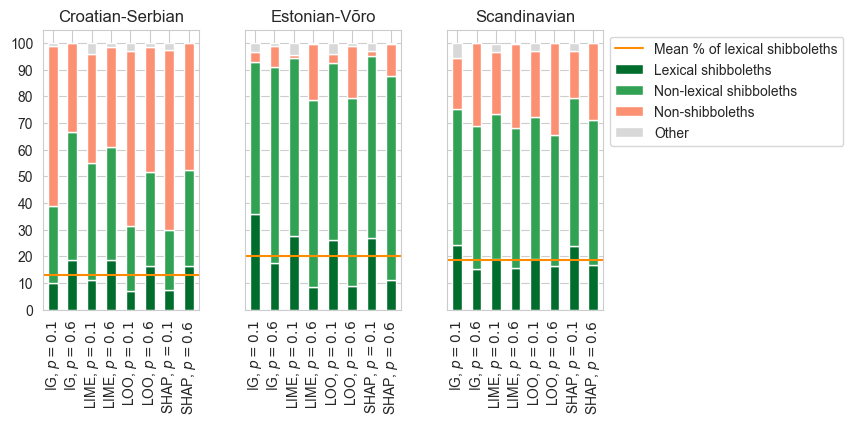

In [6]:
# in RGB 256. Picked from https://colorbrewer2.org/
colors = [(0,109,44), (49,163,84), (252,146,114), (217, 217, 217)]
colors = [tuple(e/ 256 for e in color) for color in colors]
cmap = ListedColormap(colors, name='from_list', N=4)
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=1, ncols=3, sharey='row', figsize=(7,3.5))
all_overview[all_overview['dataset'] == 'bcms_setimes'].set_index('method').plot(kind='bar', stacked=True, title="Croatian-Serbian",  colormap=cmap, ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'estonian_voro'].set_index('method').plot(kind='bar', stacked=True, title="Estonian-Võro",  colormap=cmap, ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'scandinavian_slide'].set_index('method').plot(kind='bar', stacked=True, title="Scandinavian",  colormap=cmap, ax=axes[2], legend=False)

axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)

## adding mean line
axes[2].axhline(mean_slide, color='darkorange', linestyle='-')
#axes[0].text(0, mean_slide + 0.2, f'{mean_slide:.2f}', color='darkorange', weight='bold')
axes[0].axhline(mean_set, color='darkorange', linestyle='-')
#axes[1].text(0, mean_set + 0.2, f'{mean_set:.2f}', color='darkorange')
axes[1].axhline(mean_ev, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
#axes[2].text(0, mean_ev + 0.2, f'{mean_ev:.2f}', color='darkorange')

ax=axes[1]
handles, labels = ax.get_legend_handles_labels()
print(labels)
#fig.legend(handles, labels, loc='upper center')
plt.legend(
    handles, 
    ['Mean % of lexical shibboleths', 'Lexical shibboleths', 'Non-lexical shibboleths', 'Non-shibboleths', 'Other'], 
    loc='upper left', bbox_to_anchor=(0.9, 0.9), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1,
                    wspace=0.3, hspace=0.5
                   )
fig.figure.savefig('experiment1-overview.pdf', bbox_inches='tight')

In [7]:
mean_twit = all_overview_avg.loc['bcms_twitter', 'shibboleths: lexical']
mean_suomi24 = all_overview_avg.loc['finnish_suomi24', 'shibboleths: lexical']
mean_jodel = all_overview_avg.loc['german_jodel', 'shibboleths: lexical']
mean_greek = all_overview_avg.loc['greek_dialects', 'shibboleths: lexical']

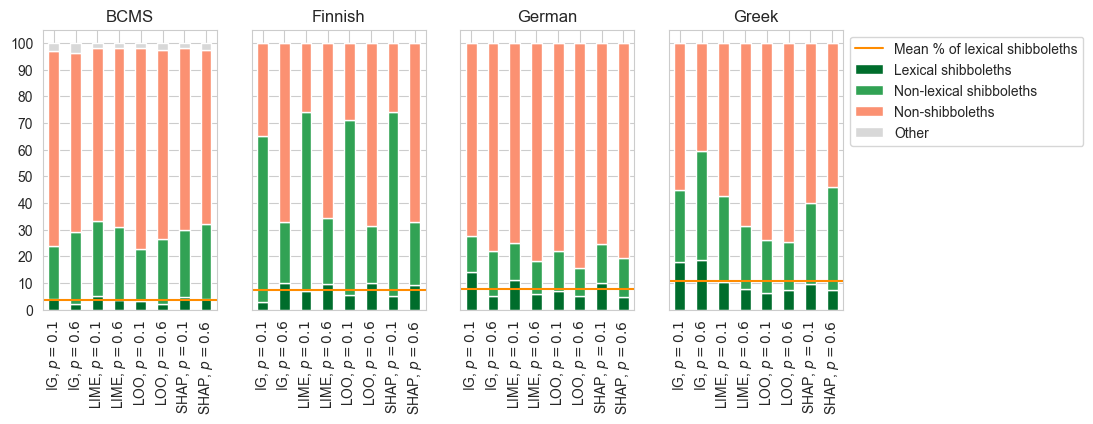

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=4, sharey='row', figsize=(10,3.5))
all_overview[all_overview['dataset'] == 'bcms_twitter'].set_index('method').plot(kind='bar', stacked=True, title="BCMS",  colormap=cmap, ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'finnish_suomi24'].set_index('method').plot(kind='bar', stacked=True, title="Finnish",  colormap=cmap, ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'german_jodel'].set_index('method').plot(kind='bar', stacked=True, title="German",  colormap=cmap, ax=axes[2], legend=False)
all_overview[all_overview['dataset'] == 'greek_dialects'].set_index('method').plot(kind='bar', stacked=True, title="Greek",  colormap=cmap, ax=axes[3], legend=False)                                                                                 
axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)
axes[3].set_xlabel(None)

axes[0].axhline(mean_twit, color='darkorange', linestyle='-')
axes[1].axhline(mean_suomi24, color='darkorange', linestyle='-')
axes[2].axhline(mean_jodel, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
axes[3].axhline(mean_greek, color='darkorange', linestyle='-')

ax=axes[2]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(
    handles, 
    ['Mean % of lexical shibboleths', 'Lexical shibboleths', 'Non-lexical shibboleths', 'Non-shibboleths', 'Other'], 
    loc='upper left', bbox_to_anchor=(0.9, 0.9), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.2, hspace=0.5
                   )
fig.figure.savefig('experiment2-overview.pdf', bbox_inches='tight')

## Plots by method and class

In [9]:
METHODS_MAP = {
    'ig_0.1': 'IG, $p=0.1$',
    'ig_0.6': 'IG, $p=0.6$',
    'lime_0.1': 'LIME, $p=0.1$',
    'lime_0.6': 'LIME, $p=0.6$',
    'loo_0.1': 'LOO, $p=0.1$',
    'loo_0.6': 'LOO, $p=0.6$',
    'shap_0.1': 'SHAP, $p=0.1$',
    'shap_0.6': 'SHAP, $p=0.6$'
}

In [80]:
def make_graphs_per_class(counts_df, outfile, nrows=2, show_legend=True):
    methods = counts_df['method'].unique()

    if len(methods) == 8:
        if nrows > 1:
            fig, axes = plt.subplots(nrows=nrows, ncols=4, sharey='row', figsize=(10,8))
        
            idx = -1
            for i in range(0,2):
                for j in range(0,4):
                    idx += 1  
                    m = methods[idx]
                    method_df = counts_df[counts_df['method'] == m]
                    method_df = method_df.drop(columns=['method'])
                    method_df = method_df.set_index('label', drop=True)
                    method_df.plot(kind='bar', stacked=True, title=METHODS_MAP[m], colormap=cmap, ax=axes[i,j], legend=False)
                    mean = method_df['Lexical shibboleths'].mean()
                # if i == 1 and j == 3:
                    axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
                    axes[i,j].get_xaxis().get_label().set_visible(False)
            
            axes[0, 0].set_yticks(range(0, 105, 10))
            axes[0, 0].set_ylim(0, 105)    
            axes[1, 0].set_yticks(range(0, 105, 10))
            axes[1, 0].set_ylim(0, 105)
            ax=axes[-1,-1]
        
        else:
            fig, axes = plt.subplots(nrows=1, ncols=8, sharey='row', figsize=(12,4))

            for i, m in enumerate(methods):
                method_df = counts_df[counts_df['method'] == m]
                method_df = method_df.drop(columns=['method'])
                method_df = method_df.set_index('label', drop=True)
                method_df.plot(kind='bar', stacked=True, title=METHODS_MAP[m], colormap=cmap, ax=axes[i], width=0.5, legend=False)
                mean = method_df['Lexical shibboleths'].mean()
                axes[i].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
                axes[i].get_xaxis().get_label().set_visible(False)

            axes[0].set_yticks(range(0, 105, 10))
            axes[0].set_ylim(0, 105)
            ax = axes[-1]
        
    else:
        fig, ax = plt.subplots(nrows=1, ncols=1, sharey='row', figsize=(2.5,4))
        m = counts_df.iloc[0]['method']
        counts_df = counts_df.drop(columns=['method'])
        counts_df = counts_df.set_index('label', drop=True)
        counts_df.plot(kind='bar', stacked=True, title=METHODS_MAP[m], colormap=cmap, ax=ax, legend=False)
        mean = counts_df['Lexical shibboleths'].mean()
        ax.axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
        ax.get_xaxis().get_label().set_visible(False)
        ax.set_yticks(range(0, 105, 10))
        ax.set_ylim(0, 105)
    
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        #fig.legend(handles, labels, loc='upper center')
        plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.9, 0.9), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

### bcms_setimes

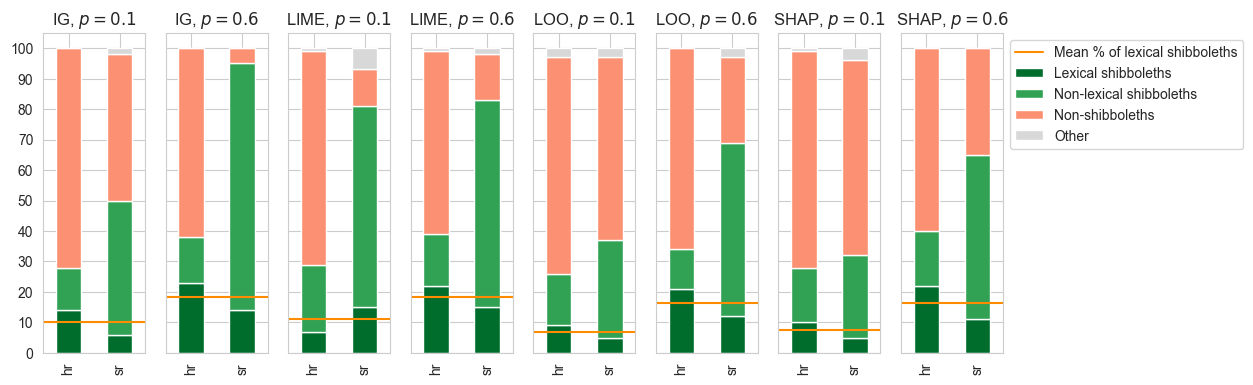

In [63]:
bcms_setimes_perclass_df = pd.read_csv('tables/bcms_setimes_perclass.csv')
make_graphs_per_class(bcms_setimes_perclass_df, 'bcms_setimes_perclass.pdf', nrows=1, show_legend=True)

### bcms_twitter

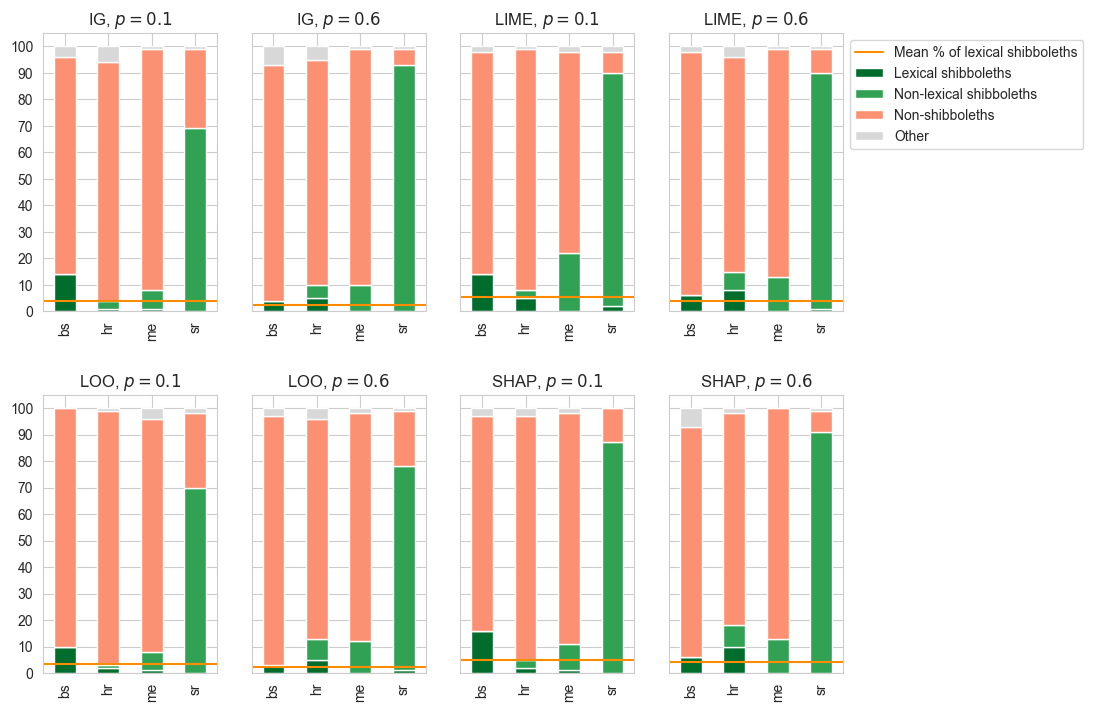

In [81]:
bcms_twitter_perclass_df = pd.read_csv('tables/bcms_twitter_perclass.csv')
make_graphs_per_class(bcms_twitter_perclass_df, 'bcms_twitter_perclass.pdf')

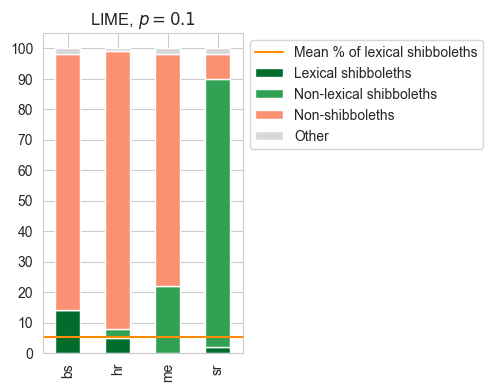

In [87]:
bcms_twitter_select_df = bcms_twitter_perclass_df[bcms_twitter_perclass_df['method'] == 'lime_0.1']
make_graphs_per_class(bcms_twitter_select_df, 'select_bcms_twitter_perclass.pdf')

### scandinavian_slide

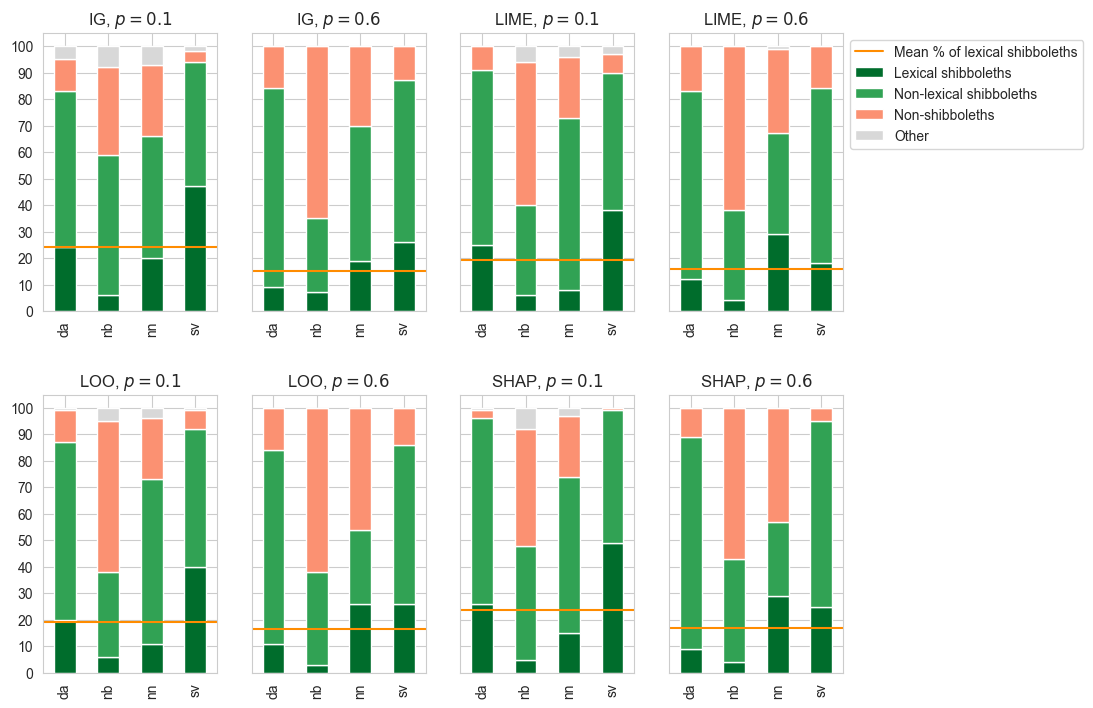

In [83]:
scandinavian_slide_perclass_df = pd.read_csv('tables/scandinavian_slide_perclass.csv')
make_graphs_per_class(scandinavian_slide_perclass_df, 'scandinavian_slide_perclass.pdf')

### estonian_voro

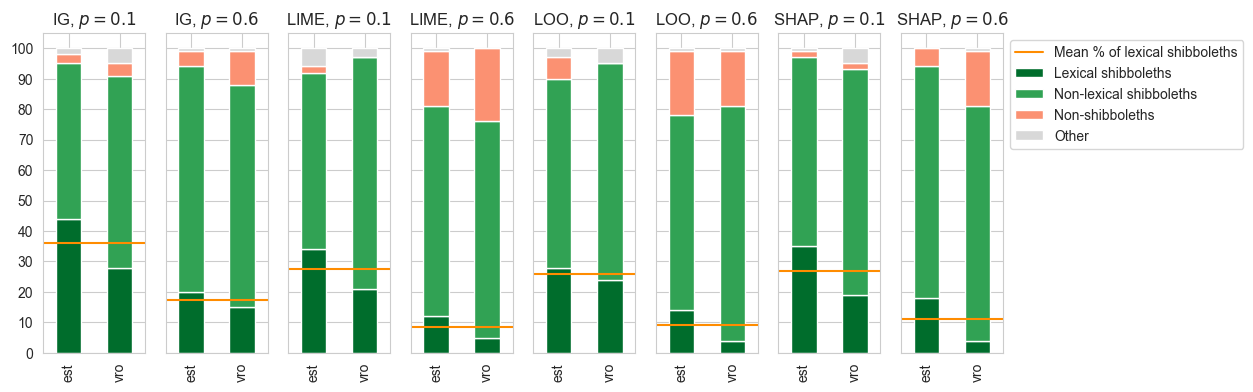

In [85]:
estonian_voro_perclass_df = pd.read_csv('tables/estonian_voro_perclass.csv')
make_graphs_per_class(estonian_voro_perclass_df, 'estonian_voro_perclass.pdf', nrows=1, show_legend=True)

### german_jodel

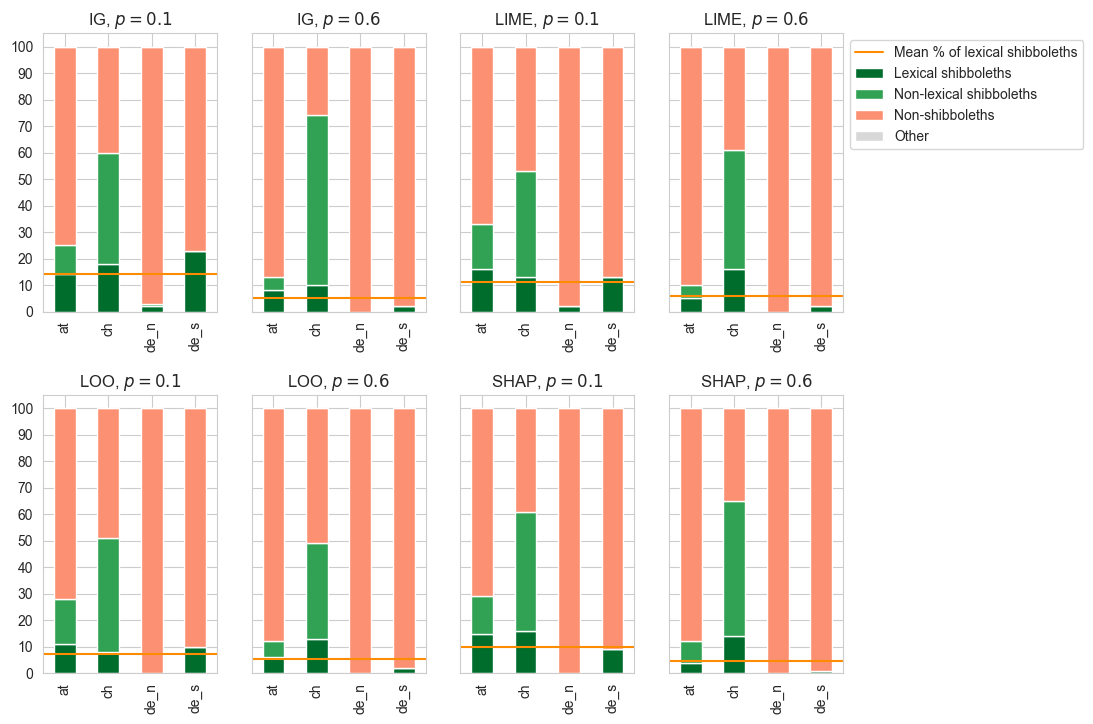

In [86]:
german_jodel_perclass_df = pd.read_csv('tables/german_jodel_perclass.csv')
make_graphs_per_class(german_jodel_perclass_df, 'german_jodel_perclass.pdf')

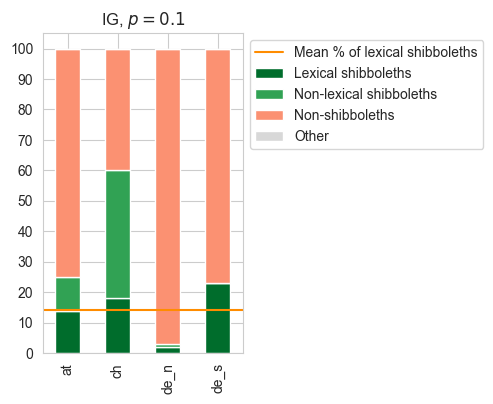

In [88]:
german_jodel_select_df = german_jodel_perclass_df[german_jodel_perclass_df['method'] == 'ig_0.1']
make_graphs_per_class(german_jodel_select_df, 'select_german_jodel_perclass.pdf')

### greek_dialects

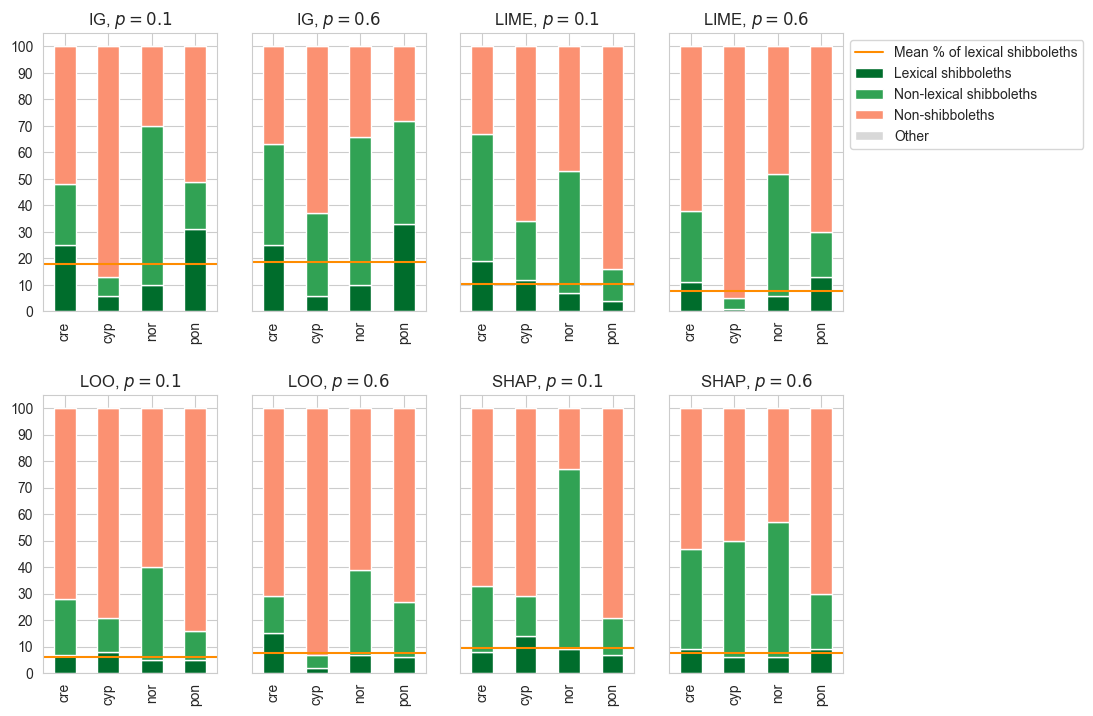

In [89]:
greek_dialects_perclass_df = pd.read_csv('tables/greek_dialects_perclass.csv')
make_graphs_per_class(greek_dialects_perclass_df, 'greek_dialects_perclass.pdf')

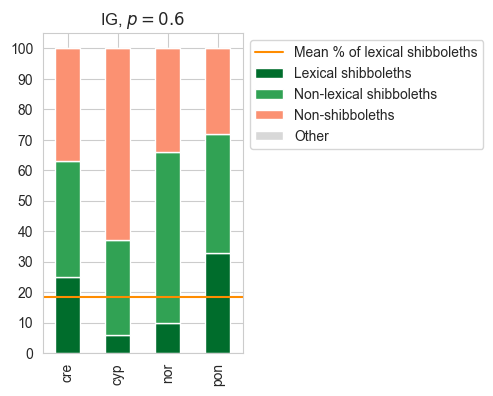

In [92]:
greek_dialects_select_df = greek_dialects_perclass_df[greek_dialects_perclass_df['method'] == 'ig_0.6']
make_graphs_per_class(greek_dialects_select_df, 'select_greek_dialects_perclass.pdf')

### finnish_suomi24

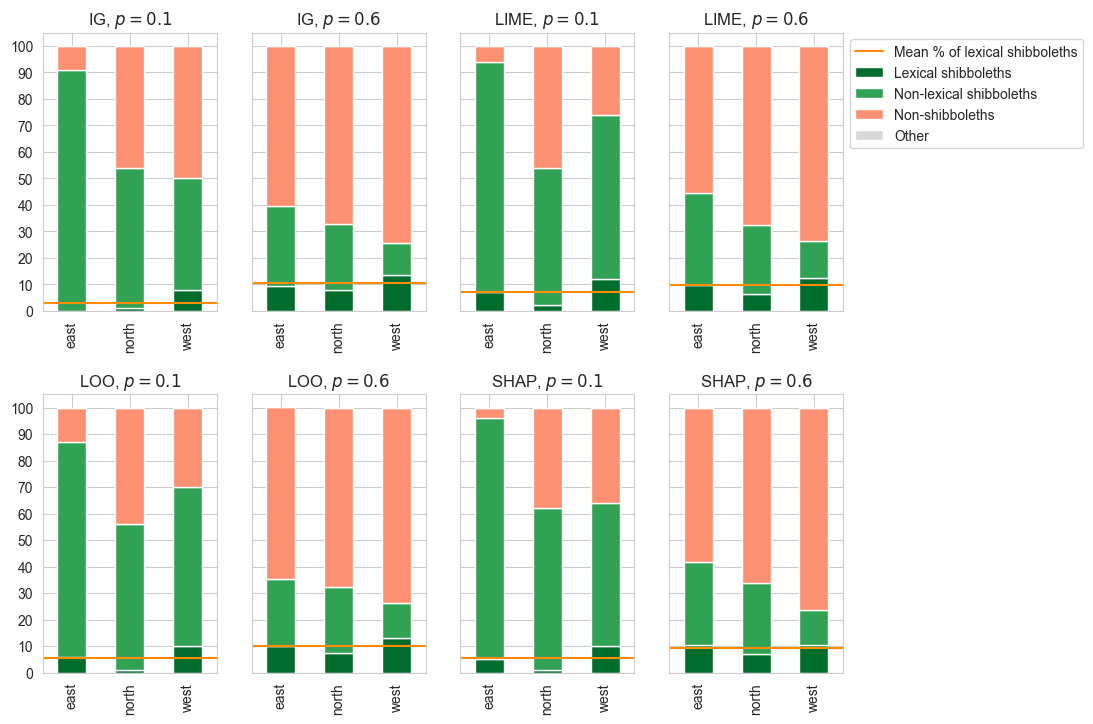

In [91]:
finnish_suomi24_perclass_df = pd.read_csv('tables/finnish_suomi24_perclass.csv')
make_graphs_per_class(finnish_suomi24_perclass_df, 'finnish_suomi24_perclass.pdf')

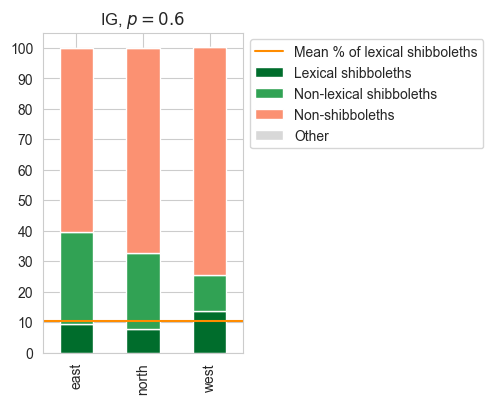

In [93]:
finnish_suomi24_select_df = finnish_suomi24_perclass_df[finnish_suomi24_perclass_df['method'] == 'ig_0.6']
make_graphs_per_class(finnish_suomi24_select_df, 'select_finnish_suomi24_perclass.pdf')

In [ ]:
def make_graphs_per_class_unused_1(dict, ds):
    
    counts = dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df
    
    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
    
    idx = -1
    for i in range(0,2):
        for j in range(0,4):
            idx += 1  
            m = methods[idx]
            counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
            mean = counts_df.loc[m]['Lexical'].mean()
           # if i == 1 and j == 3:
            axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    ax=axes[1,3]
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center')
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

In [ ]:
def make_graphs_per_class_unused_2(dict, ds):
    
    counts = dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df
    
    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
    
    idx = -1
    for i in range(0,2):
        for j in range(0,4):
            idx += 1  
            m = methods[idx]
            counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
            mean = counts_df.loc[m]['Lexical'].mean()
           # if i == 1 and j == 3:
            axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    ax=axes[1,3]
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center')
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

# LEVELS OF LINGUISTIC STRUCTURE

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

def levels_to_pie(levels_df, selected_config, savename):
    my_df_ = levels_df.reset_index().sort_values(['feature', 'method', 'label']).pivot(index=['method', 'feature'], columns='label', values='count').reset_index()
    labels = levels_df.reset_index().label.unique()
    my_df_ = my_df_[my_df_['method'] == selected_config]

    print(my_df_)
    fig, axes = plt.subplots(nrows=1, ncols=len(labels), figsize=(4 * len(labels), 4))
    font_size = 16

    # always associate the same feature with the same color
    colors = {'lex': mpl.colormaps['Set2'].colors[0], 'morph': mpl.colormaps['Set2'].colors[1], 'phon': mpl.colormaps['Set2'].colors[2], 'spel': mpl.colormaps['Set2'].colors[3]}
    names = {'lex': 'Lexicon', 'morph': 'Morphology', 'phon': 'Phonetics', 'spel': 'Spelling'}
    cmap = ListedColormap([colors[x] for x in colors if x in my_df_["feature"].unique()])
    
    for idx, label in enumerate(sorted(labels)):
        display_df = my_df_[[label, 'feature']]
        display_df = display_df.set_index('feature')
        display_df.plot(
            kind='pie', 
            y=label, 
            colormap=cmap,
            legend=False,
            labels=None,
            ax=axes[idx],
            title=label,
            xlabel=None,
            ylabel=None,
            autopct=lambda p: '{:.1f}%'.format(round(p)) if p > 0 else '',
            textprops={'size': font_size}
        )
        axes[idx].set_ylabel(None)
        axes[idx].title.set_size(font_size)

    #legend
    patches = [mpatches.Patch(color=colors[c], label=names[c]) for c in colors]
    plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1.1, 0.5), prop={'size': font_size})
    
    plt.tight_layout()
    fig.savefig(savename, bbox_inches='tight')

In [ ]:
# not used, replaced by pie charts
def make_graphs_per_level(df, methods, classes, dataset):
    
    work_df = df
    methods = methods
    classes = classes
    ds = dataset
    dfs = []
    outfile = dataset + '_perlevel.pdf'

    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
        
    
    i = 0
    j = -1
    for m in methods:
        j += 1
        for c in classes:
            tmp = work_df.loc[(m, c)] ## indendted
            tmp['sum'] = tmp['count'].sum()
            tmp['perc'] = round(tmp['count'] / tmp['sum'] * 100, 1)
            tmp = tmp.drop(columns=['count', 'sum']).transpose()
            tmp['label'] = c
            tmp = tmp.set_index('label')
            dfs.append(tmp)

        df_to_plot = pd.concat(dfs).sort_index(axis=1)    
        print(df_to_plot)
        df_to_plot.plot(kind='bar', stacked=True, title = m, colormap='summer', ax = axes[i,j], legend=False)
    
        dfs = []
        
        if j == 3:
            i += 1
            j = -1
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    axes[0,0].set_xlabel(None)
    axes[0,1].set_xlabel(None)
    axes[0,2].set_xlabel(None)
    axes[0,3].set_xlabel(None)
    axes[1,0].set_xlabel(None)
    axes[1,1].set_xlabel(None)
    axes[1,2].set_xlabel(None)
    axes[1,3].set_xlabel(None)
    
    ax=axes[0,2]
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.97, 0.7), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

In [ ]:
def make_sel_graph_per_level(df, method, classes, dataset):
    
    work_df = df
    m = method
    classes = classes
    ds = dataset
    dfs = []
    outfile = dataset + '_perlevel_sel.barh.pdf'

    #fig  = plt.plot(figsize=(5,4))
    for c in classes:
        try: ## added
            tmp = work_df.loc[m, c] ## indented
            tmp['sum'] = tmp['count'].sum()
            tmp['perc'] = round(tmp['count'] / tmp['sum'] * 100, 1)
            tmp = tmp.drop(columns=['sum', 'perc']).transpose()
            tmp['label'] = c
            tmp = tmp.set_index('label')
            dfs.append(tmp)
        except KeyError:
            pass
    print(dfs)

    df_to_plot = pd.concat(dfs).sort_index(axis=1)
    g = df_to_plot.plot(
        kind='barh',
        xlim=(0, 100),
        stacked=True,
        color={'lex': '#006d2c', 'morph': '#31a354', 'phon': '#74c476', 'spel': '#a1d99b' },
        figsize=(5, 2),
        ylabel=None, 
        fontsize=16,
    )
    g.set(ylabel=None)
    g.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), labels=['Lexicon', 'Morphology', 'Phonetics', 'Spelling']).figure.savefig(outfile, bbox_inches='tight')
    
    
   # plt.set_yticks(range(0, 105, 10))
   # plt.set_ylim(0, 105)
    
#    axes[1, 0].set_yticks(range(0, 105, 10))
#    axes[1, 0].set_ylim(0, 105)
#    
#    axes[0,0].set_xlabel(None)
#    axes[0,1].set_xlabel(None)
#    axes[0,2].set_xlabel(None)
#    axes[0,3].set_xlabel(None)
#    axes[1,0].set_xlabel(None)
#    axes[1,1].set_xlabel(None)
#    axes[1,2].set_xlabel(None)
#    axes[1,3].set_xlabel(None)
    
#    ax=axes[0,2]
#    handles, labels = ax.get_legend_handles_labels()
#    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.97, 0.7), bbox_transform=plt.gcf().transFigure)
#   # plt.subplots_adjust(left=0.1, right=0.9, 
#                        top=0.9, bottom=0.1, 
#                        wspace=0.2, hspace=0.3
#                       )
    
   # plt.figure.savefig(outfile, bbox_inches='tight')

### PREPARING BCMS SETIMES

In [ ]:
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
file,,,,,,,,,,
list6,natjecateljskom,hr,0.241601,0.70,True,yes,lex,NaN,NaN,lime_0.6
list6,liječniku,hr,0.232991,0.67,True,yes,lex,NaN,jek,lime_0.6
list6,slijedili,hr,0.228810,0.69,True,no,phon,NaN,jek,lime_0.6
list6,natjecalo,hr,0.221181,0.66,True,yes,lex,NaN,NaN,lime_0.6
list6,strijelac,hr,0.211338,0.87,True,no,phon,NaN,jek,lime_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,ig_0.6
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,ig_0.6
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,ig_0.6


In [ ]:
f1 = bcms_setimes_df2[['feature', 'label']]
len(f1)

1600

In [ ]:
f2 = bcms_setimes_df2[['feature2', 'label']].dropna()
f2['feature'] = f2['feature2']
f2 = f2.drop(columns=['feature2'])
len(f2)

99

In [ ]:
feature_df = pd.concat([f1, f2])
feature_df = feature_df.reset_index(drop=False)
feature_df = feature_df[feature_df.feature.str.contains('phon|lex|morph-d|morph-f|spel')]
feature_df = feature_df.join(bcms_setimes_methods_df, how='left', on='file').drop(columns=('file'))
feature_df["feature"] = feature_df["feature"].str.replace("morph-d", "morph").replace("morph-f", "morph")
feature_df
# per method, per class

,feature,label,method
0,lex,hr,lime_0.6
1,lex,hr,lime_0.6
2,phon,hr,lime_0.6
3,lex,hr,lime_0.6
4,phon,hr,lime_0.6
...,...,...,...
1670,morph,hr,loo_0.1
1674,phon,sr,loo_0.1
1680,phon,hr,ig_0.6
1686,phon,hr,ig_0.6


In [ ]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [ ]:
classes = feature_df['label'].sort_values().unique()
classes

array(['hr', 'sr'], dtype=object)

In [ ]:
bcms_setimes_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
bcms_setimes_levels_df

count
method   label feature       
ig_0.1   hr    lex         14
               morph        4
               phon        64
               spel         1
         sr    lex          7
               morph       17
               phon        27
               spel         2
ig_0.6   hr    lex         23
               morph        6
               phon        72
         sr    lex         14
               morph        8
               phon        73
               spel         1
lime_0.1 hr    lex          7
               morph       21
               phon        37
               spel         2
         sr    lex         15
               morph       29
               phon        38
lime_0.6 hr    lex         22
               morph       17
               phon        51
         sr    lex         15
               morph       22
               phon        48
               spel         1
loo_0.1  hr    lex          9
               morph       15
               phon        40
               spel         2
         sr    lex          5
               morph       13
               phon        20
loo_0.6  hr    lex         21
               morph       13
               phon        50
         sr    lex         12
               morph       10
               phon        47
               spel         1
shap_0.1 hr    lex         10
               morph       16
               phon        49
               spel         1
         sr    lex          5
               morph       10
               phon        19
               spel         1
shap_0.6 hr    lex         22
               morph       14
               phon        59
               spel         1
         sr    lex         11
               morph       13
               phon        43

label    method feature    hr    sr
8      lime_0.1     lex   7.0  15.0
9      lime_0.1   morph  21.0  29.0
10     lime_0.1    phon  37.0  38.0
11     lime_0.1    spel   2.0   NaN


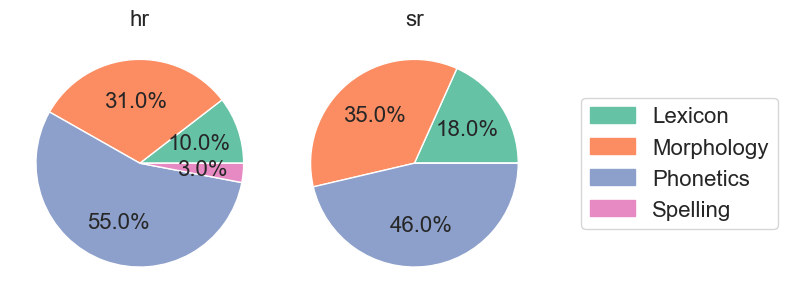

In [ ]:
levels_to_pie(bcms_setimes_levels_df, 'lime_0.1', 'bcms_setimes_lime_0.1_pie.pdf')

In [ ]:
bcms_setimes_levels_df.reset_index().label.unique()

array(['hr', 'sr'], dtype=object)

[feature  lex  morph  phon  spel
label                          
hr         7     21    37     2, feature  lex  morph  phon
label                    
sr        15     29    38]


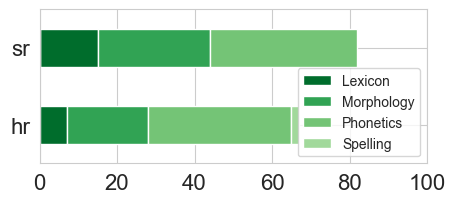

In [ ]:
make_sel_graph_per_level(bcms_setimes_levels_df, 'lime_0.1', classes, 'bcms_setimes')

### PREPARING BCMS TWITTER

In [ ]:
bcms_twitter_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
file,,,,,,,,,,
list6,😎🌞<unk>☕️🍉,bs,1.525842,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,☕️😎,bs,1.430635,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,unk>😏,bs,1.371145,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,🙈<unk>🙊,bs,1.352293,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,👍😏,bs,1.306748,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
...,...,...,...,...,...,...,...,...,...,...
list8,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,lime_0.1
list8,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,lime_0.1
list8,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,lime_0.1


In this setup, it is possible to have non-shibboleths annotated for linguistic features

(a word can be marked, just not specific to a single variety)

In [ ]:
f1 = bcms_twitter_df2[bcms_twitter_df2['shibboleth'] == 'yes'][['feature', 'label']]
f1

,feature,label
file,,
list6,lex,bs
list6,lex,bs
list6,lex,bs
list6,lex,bs
list6,lex,bs
...,...,...
list8,phon,sr
list8,phon,sr
list8,phon,sr


In [ ]:
f2 = bcms_twitter_df2[bcms_twitter_df2['shibboleth'] ==  'yes'][['feature2', 'label']].dropna()
f2['feature'] = f2['feature2']
f2 = f2.drop(columns=['feature2'])
f2

,label,feature
file,,
list6,bs,spel
list6,bs,spel
list6,bs,nonminimal
list6,bs,nonminimal
list6,bs,nonminimal
...,...,...
list8,me,spel
list8,sr,morph-f
list8,sr,nonminimal


In [ ]:
feature_df = pd.concat([f1, f2])
#feature_df['file'] = feature_df.index
feature_df = feature_df.reset_index() #.drop(columns=('index'))
feature_df = feature_df[feature_df.feature.str.contains('phon|lex|morph-d|morph-f|spel')]
feature_df = feature_df.join(bcms_setimes_methods_df, how='left', on='file').drop(columns=('file'))
feature_df["feature"] = feature_df["feature"].str.replace("morph-d", "morph").replace("morph-f", "morph")
feature_df

,feature,label,method
0,lex,bs,lime_0.6
1,lex,bs,lime_0.6
2,lex,bs,lime_0.6
3,lex,bs,lime_0.6
4,lex,bs,lime_0.6
...,...,...,...
1024,spel,me,ig_0.6
1025,spel,me,ig_0.6
1026,spel,me,ig_0.6
1027,morph,sr,ig_0.6


In [ ]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [ ]:
classes = feature_df['label'].sort_values().unique()
classes

array(['bs', 'hr', 'me', 'sr'], dtype=object)

In [ ]:
bcms_twitter_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
bcms_twitter_levels_df

count
method   label feature       
ig_0.1   bs    lex          3
               spel         2
         hr    lex          5
               morph        2
               phon         6
...                       ...
shap_0.6 me    lex          1
               phon        10
               spel         4
         sr    morph        1
               phon        87

[80 rows x 1 columns]

label    method feature   bs    hr    me    sr
8      lime_0.1     lex  6.0  10.0   NaN   1.0
9      lime_0.1   morph  NaN   3.0   NaN   NaN
10     lime_0.1    phon  NaN   7.0  13.0  91.0
11     lime_0.1    spel  2.0   NaN   2.0   NaN


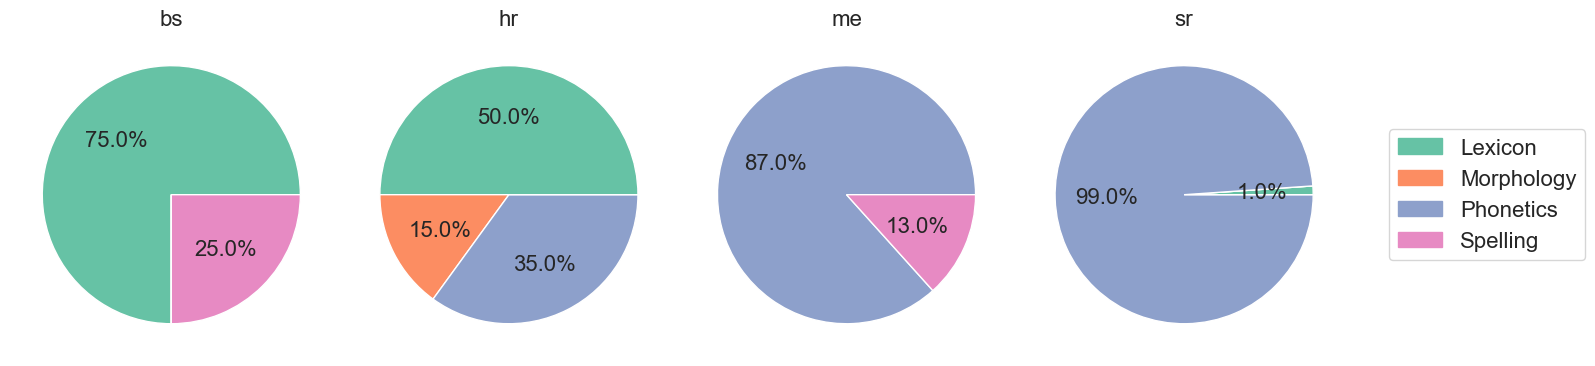

In [ ]:
levels_to_pie(bcms_twitter_levels_df, 'lime_0.1', 'bcms_twitter_lime_0.1_pie.pdf')

In [ ]:
# make_graphs_per_level(bcms_twitter_levels_df, methods, classes, 'bcms_twitter')

[feature  lex  spel
label             
bs         6     2, feature  lex  morph  phon
label                    
hr        10      3     7, feature  phon  spel
label              
me         13     2, feature  lex  phon
label             
sr         1    91]


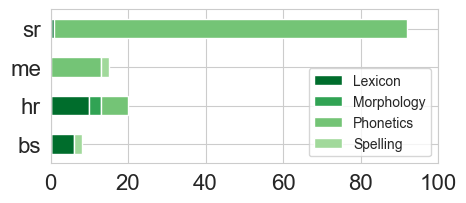

In [ ]:
make_sel_graph_per_level(bcms_twitter_levels_df, 'lime_0.1', classes, 'bcms_twitter')

## PREPARING FINNISH

In [ ]:
finnish_suomi24_df2

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,method
file,,,,,,,,
list8,0,täötyy,east,0.863224,0.101010,phon,other,shap_0.1
list8,1,pahimoelleen,east,0.847876,0.101010,phon,other,shap_0.1
list8,2,sullakii,east,0.826737,0.202020,morph,other,shap_0.1
list8,3,paekkaan,east,0.811686,0.101010,phon,other,shap_0.1
list8,4,piästii,east,0.804127,0.101010,phon,other,shap_0.1
...,...,...,...,...,...,...,...,...
list7,295,varovainen,west,0.258827,0.101010,not,not,ig_0.1
list7,296,miä,west,0.258084,0.161616,lex,lex,ig_0.1
list7,297,nää,west,0.257057,0.191919,not,not,ig_0.1


In [ ]:
feature_df = finnish_suomi24_df2[(finnish_suomi24_df2['lex_other_not'] == 'lex') | (finnish_suomi24_df2['lex_other_not'] == 'other')][['category', 'label', 'method']]
feature_df = feature_df[feature_df.category.str.contains('morph|lex|phon')]
feature_df

,category,label,method
file,,,
list8,phon,east,shap_0.1
list8,phon,east,shap_0.1
list8,morph,east,shap_0.1
list8,phon,east,shap_0.1
list8,phon,east,shap_0.1
...,...,...,...
list7,lex,west,ig_0.1
list7,lex,west,ig_0.1
list7,phon,west,ig_0.1


In [ ]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [ ]:
classes = feature_df['label'].sort_values().unique()
classes

array(['east', 'north', 'west'], dtype=object)

In [ ]:
finnish_suomi24_levels_df = feature_df.rename(columns={'category': 'feature'}).groupby(['method', 'label', 'feature']).size().to_frame(name='count')
finnish_suomi24_levels_df

count
method   label feature       
ig_0.1   east  morph       24
               phon        67
         north lex          1
               morph       22
               phon        27
...                       ...
shap_0.6 north morph        8
               phon        11
         west  lex          7
               morph        1
               phon         8

[71 rows x 1 columns]

In [ ]:
#make_graphs_per_level(finnish_suomi24_levels_df, methods, classes, 'finnish_suomi24-test')

[feature  lex  morph  phon
label                    
east       6      6    13, feature  lex  morph  phon
label                    
north      5      8     8, feature  lex  morph  phon
label                    
west       8      1     6]


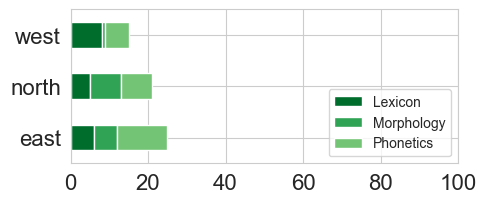

In [ ]:
make_sel_graph_per_level(finnish_suomi24_levels_df, 'ig_0.6', classes, 'finnish_suomi24')

label  method feature  east  north  west
3      ig_0.6     lex   6.0    5.0   8.0
4      ig_0.6   morph   6.0    8.0   1.0
5      ig_0.6    phon  13.0    8.0   6.0


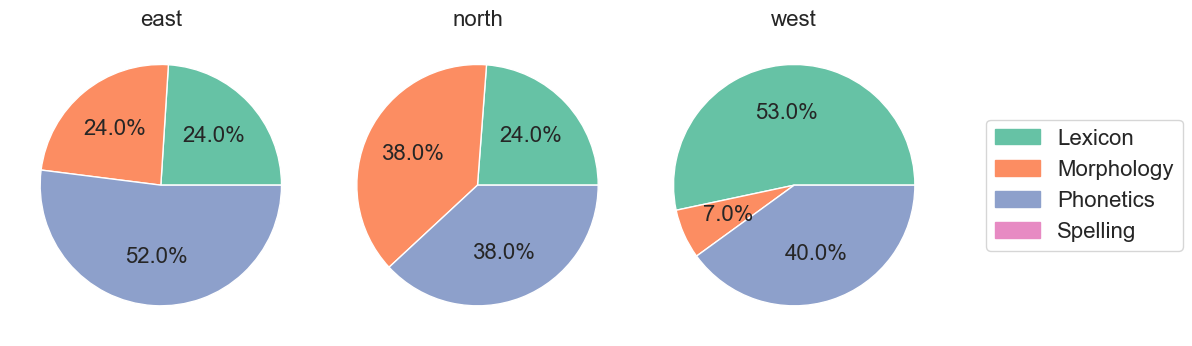

In [ ]:
levels_to_pie(finnish_suomi24_levels_df, 'ig_0.6', 'finnish_suomi24_ig_0.6_pie.pdf')


### PREPARING GREEK 

In [ ]:
greek_dialects_df2['feature'].sort_values().unique()

array(['I', 'Lex', 'Morph', 'NE', 'Other', 'Phon', 'Spell', 'Unmarked',
       'ΝΕ'], dtype=object)

In [ ]:
feature_df = greek_dialects_df2[['feature', 'label', 'method']]
feature_df = feature_df[feature_df.feature.str.contains('Morph|Lex|Phon|Spell')]
feature_df['feature'] =  feature_df['feature'].str.lower().replace("spell", "spel")
feature_df

,feature,label,method
file,,,
list6,lex,cre,ig_0.1
list6,morph,cre,ig_0.1
list6,phon,cre,ig_0.1
list6,lex,cre,ig_0.1
list6,lex,cre,ig_0.1
...,...,...,...
list8,morph,pon,lime_0.1
list8,morph,pon,lime_0.1
list8,lex,pon,lime_0.1


In [ ]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [ ]:
classes = feature_df['label'].sort_values().unique()
classes

array(['cre', 'cyp', 'nor', 'pon'], dtype=object)

In [ ]:
greek_dialects_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
greek_dialects_levels_df

count
method   label feature       
ig_0.1   cre   lex         25
               morph       14
               phon         9
         cyp   lex          6
               morph        2
...                       ...
shap_0.6 nor   morph       13
               phon        38
         pon   lex          9
               morph       13
               phon         8

[96 rows x 1 columns]

label  method feature   cre   cyp   nor   pon
3      ig_0.6     lex  25.0   6.0  10.0  33.0
4      ig_0.6   morph  17.0   4.0  18.0  23.0
5      ig_0.6    phon  19.0  25.0  38.0  16.0
6      ig_0.6    spel   1.0   NaN   NaN   NaN


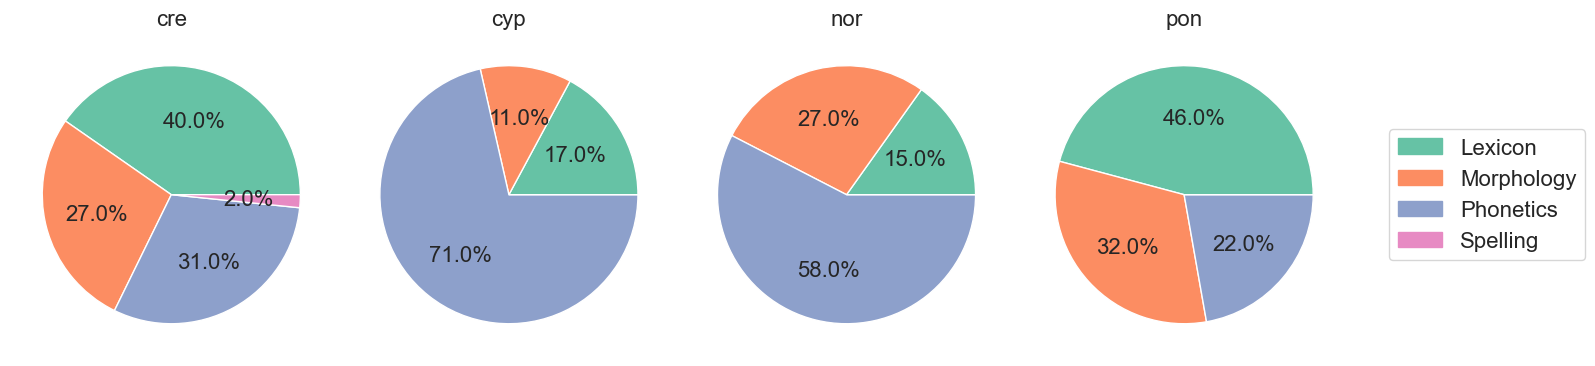

In [ ]:
levels_to_pie(greek_dialects_levels_df, 'ig_0.6', 'greek_dialects_ig_0.6_pie.pdf')

[feature  lex  morph  phon  spel
label                          
cre       25     17    19     1, feature  lex  morph  phon
label                    
cyp        6      4    25, feature  lex  morph  phon
label                    
nor       10     18    38, feature  lex  morph  phon
label                    
pon       33     23    16]


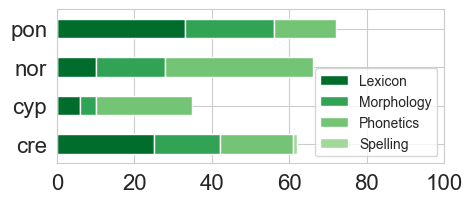

In [ ]:
make_sel_graph_per_level(greek_dialects_levels_df, 'ig_0.6', classes, 'greek_dialects')

### PREPARING JODEL

In [ ]:
german_jodel_df2[german_jodel_df2['shibboleth'] == 'yes']['code'].sort_values().unique()

array(['lex', 'morph', 'other', 'phon', 'spell'], dtype=object)

In [ ]:
feature_df = german_jodel_df2[german_jodel_df2['shibboleth'] == 'yes'][['label', 'method', 'code']]
feature_df = feature_df[feature_df.code.str.contains('morph|lex|phon|spell')]
feature_df['code'] =  feature_df['code'].str.replace("spell", "spel")
feature_df = feature_df.rename(columns={'code': 'feature'})
feature_df

,label,method,feature
file,,,
list6,at,shap_0.1,morph
list6,at,shap_0.1,morph
list6,at,shap_0.1,morph
list6,at,shap_0.1,lex
list6,at,shap_0.1,morph
...,...,...,...
list8,ch,loo_0.6,phon
list8,ch,loo_0.6,morph
list8,ch,loo_0.6,phon


In [ ]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [ ]:
classes = feature_df['label'].sort_values().unique()
classes

array(['at', 'ch', 'de_n', 'de_s'], dtype=object)

In [ ]:
german_jodel_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
german_jodel_levels_df

count
method   label feature       
ig_0.1   at    lex         14
               morph        7
               phon         4
         ch    lex         18
               morph        4
               phon        38
         de_n  lex          2
         de_s  lex         23
ig_0.6   at    lex          8
               morph        5
         ch    lex         10
               morph       15
               phon        49
         de_s  lex          2
lime_0.1 at    lex         16
               morph       16
               phon         1
         ch    lex         13
               morph       13
               phon        27
         de_n  lex          2
         de_s  lex         13
lime_0.6 at    lex          5
               morph        5
         ch    lex         16
               morph       18
               phon        27
         de_s  lex          2
loo_0.1  at    lex         11
               morph       15
               phon         2
         ch    lex          8
               morph       14
               phon        27
               spel         2
         de_s  lex         10
loo_0.6  at    lex          6
               morph        6
         ch    lex         13
               morph       14
               phon        21
               spel         1
         de_s  lex          2
shap_0.1 at    lex         15
               morph       12
               phon         2
         ch    lex         16
               morph       10
               phon        33
               spel         2
         de_s  lex          9
shap_0.6 at    lex          4
               morph        7
               phon         1
         ch    lex         14
               morph       20
               phon        31
         de_s  lex          1

label  method feature    at    ch  de_n  de_s
0      ig_0.1     lex  14.0  18.0   2.0  23.0
1      ig_0.1   morph   7.0   4.0   NaN   NaN
2      ig_0.1    phon   4.0  38.0   NaN   NaN


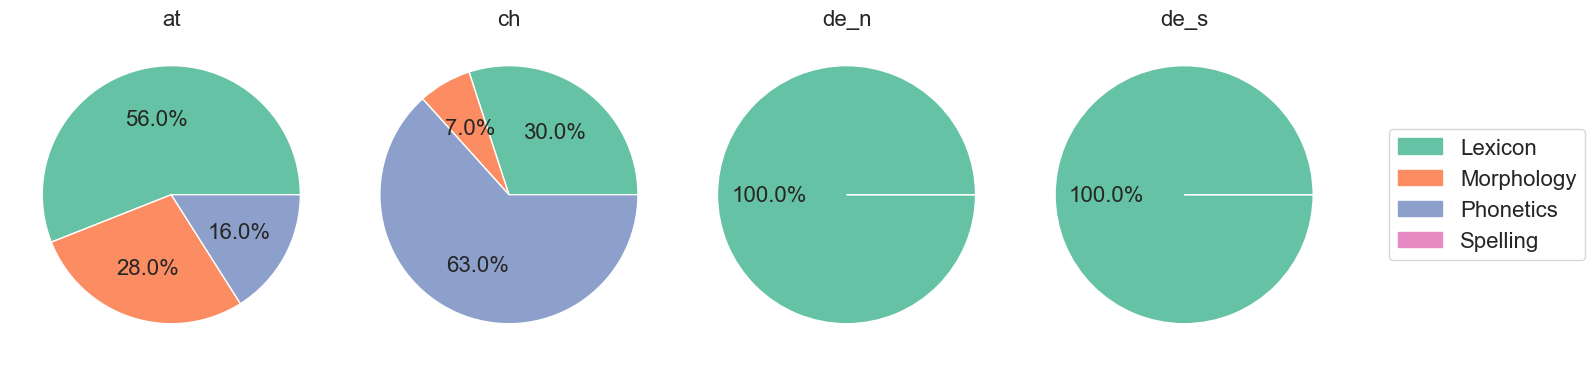

In [ ]:
levels_to_pie(german_jodel_levels_df, 'ig_0.1', 'german_jodel_ig_0.1_pie.pdf')

[feature  lex  morph  phon
label                    
at        14      7     4, feature  lex  morph  phon
label                    
ch        18      4    38, feature  lex
label       
de_n       2, feature  lex
label       
de_s      23]


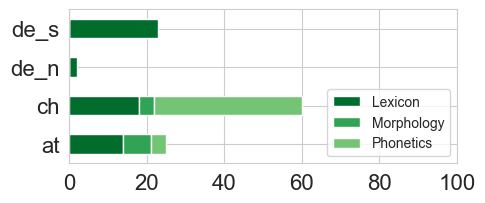

In [ ]:
make_sel_graph_per_level(german_jodel_levels_df, 'ig_0.1', classes, 'german_jodel')

### PREPARING SLIDE

In [ ]:
scandinavian_slide_df2

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,method
file,,,,,,,,,,,,,,,,,,,,
list3,0,ydmyghed,da,1.008674,0.10,False,NaN,ydmykhet,audmykt,ödmjukhet,False,False,True,True,False,False,False,False,True,shap_0.1
list3,1,styrtregnede,da,1.000334,0.10,False,NaN,styrtregnet,styrtregna,NaN,False,False,True,False,False,False,False,False,True,shap_0.1
list3,2,broderede,da,1.000113,0.10,False,NaN,broderte,NaN,broderade,False,False,True,False,False,False,False,False,True,shap_0.1
list3,3,åbningsudsalg,da,0.999946,0.10,False,NaN,åpningssalg?,NaN,öppningsrea?,False,False,False,False,False,False,True,False,False,shap_0.1
list3,4,orddelingsfejl,da,0.999925,0.10,False,NaN,orddelingsfeil,NaN,NaN,False,False,False,True,False,False,False,False,True,shap_0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
list8,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,lime_0.6
list8,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,lime_0.6
list8,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,lime_0.6


In [ ]:
feature_df = scandinavian_slide_df2[(scandinavian_slide_df2['LexShib'] == True) | \
                                    (scandinavian_slide_df2['NonLexShib'] == True)][['Morph', 'Phon_Spell', 'LexShib', 'method', 'label']]
feature_df['LexShib'] = feature_df['LexShib'].replace(True, 'Lex')
feature_df['Morph'] = feature_df['Morph'].replace(True, 'Morph')
feature_df['Phon_Spell'] = feature_df['Phon_Spell'].replace(True, 'Phon_Spell')
feature_df

,Morph,Phon_Spell,LexShib,method,label
file,,,,,
list3,Morph,Phon_Spell,False,shap_0.1,da
list3,Morph,False,False,shap_0.1,da
list3,Morph,False,False,shap_0.1,da
list3,False,False,Lex,shap_0.1,da
list3,False,Phon_Spell,False,shap_0.1,da
...,...,...,...,...,...
list8,False,False,Lex,lime_0.6,sv
list8,False,Phon_Spell,False,lime_0.6,sv
list8,Morph,Phon_Spell,False,lime_0.6,sv


In [ ]:
tmp1 = feature_df[['Morph', 'method', 'label']]
tmp1['feature'] = tmp1['Morph']
tmp1 = tmp1.drop(columns=['Morph'])
tmp1

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/2651079599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['feature'] = tmp1['Morph']


,method,label,feature
file,,,
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,False
list3,shap_0.1,da,False
...,...,...,...
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False
list8,lime_0.6,sv,Morph


In [ ]:
tmp2 = feature_df[['LexShib', 'method', 'label']]
tmp2['feature'] = tmp2['LexShib']
tmp2 = tmp2.drop(columns=['LexShib'])
tmp2

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/2370939929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['feature'] = tmp2['LexShib']


,method,label,feature
file,,,
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,Lex
list3,shap_0.1,da,False
...,...,...,...
list8,lime_0.6,sv,Lex
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False


In [ ]:
tmp3 = feature_df[['Phon_Spell', 'method', 'label']]
tmp3['feature'] = tmp3['Phon_Spell']
tmp3 = tmp3.drop(columns=['Phon_Spell'])
tmp3

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/2819609312.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp3['feature'] = tmp3['Phon_Spell']


,method,label,feature
file,,,
list3,shap_0.1,da,Phon_Spell
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,Phon_Spell
...,...,...,...
list8,lime_0.6,sv,False
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell


In [ ]:
feature_df = pd.concat([tmp1, tmp2, tmp3])
feature_df = feature_df[feature_df['feature'] != False]
feature_df

,method,label,feature
file,,,
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
...,...,...,...
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell


In [ ]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [ ]:
classes = feature_df['label'].sort_values().unique()
classes

array(['da', 'nb', 'nn', 'sv'], dtype=object)

In [ ]:
scandinavian_slide_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
scandinavian_slide_levels_df

count
method   label feature          
ig_0.1   da    Lex            24
               Morph          14
               Phon_Spell     48
         nb    Lex             6
               Morph          29
...                          ...
shap_0.6 nn    Morph          13
               Phon_Spell     17
         sv    Lex            25
               Morph          31
               Phon_Spell     55

[96 rows x 1 columns]

In [ ]:
#make_graphs_per_level(scandinavian_slide_levels_df, methods, classes, 'scandinavian_slide')

In [ ]:

bcms_twitter_levels_df.to_csv('bcms_levels.csv', index=False)
finnish_suomi24_levels_df.to_csv('bcms_levels.csv', index=False)
greek_dialects_levels_df.to_csv('bcms_levels.csv', index=False)
german_jodel_levels_df.to_csv('bcms_levels.csv', index=False)
